# Exemplo de treinamento para as bases de dados: Classificação e Regressão.

----



### Carregamento das Bases de Dados
Agora, vamos carregar os arquivos CSV para inspecionar os dados.

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import pandas as pd

base_ml = pd.read_csv('./drive/MyDrive/Projeto GNG/v2/base_discentes_semestre_ml.csv')
base_flat = pd.read_csv('./drive/MyDrive/Projeto GNG/v2/base_flat_por_aluno.csv')
base_seq = pd.read_csv('./drive/MyDrive/Projeto GNG/v2/base_sequencial_por_semestre.csv')

print("Base ML:")
display(base_ml.head())
print("Base Flat:")
display(base_flat.head())
print("Base Sequencial:")
display(base_seq.head())

Base ML:


,id_discente,ano_ingresso,periodo_ingresso,semestre_cronologico,renda,sexo_encoded,ano_nascimento,raca_encoded,escola_ens_medio_encoded,cotista_encoded,...,ECT2301_faltas,ECT2302_faltas,ECT2303_faltas,ECT2304_faltas,ECT2305_faltas,ECT2306_faltas,ECT2307_faltas,ECT2401_faltas,ECT2402_faltas,ECT2403_faltas
0,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,1.0,1302.0,0,1983.0,5,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,2.0,1302.0,0,1983.0,5,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0012eec874bff4c326e63521912828fb,2010,1.0,1.0,1200.0,1,1991.0,4,-1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0012eec874bff4c326e63521912828fb,2010,1.0,2.0,1200.0,1,1991.0,4,-1,0,...,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0
4,0012eec874bff4c326e63521912828fb,2010,1.0,3.0,1200.0,1,1991.0,4,-1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Base Flat:


,id_discente,ano_ingresso,periodo_ingresso,concluiu,semestres_para_concluir,renda,sexo_encoded,ano_nascimento,raca_encoded,escola_ens_medio_encoded,...,s4_ECT2401_status,s4_ECT2402_nota,s4_ECT2402_status,s4_ECT2403_nota,s4_ECT2403_status,s4_faltas_no_periodo,s4_media_periodo,s4_reprovacoes_no_periodo,s4_total_faltas_acumulado,s4_total_reprovacoes_acumulado
0,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,0.0,2.0,1302.0,0,1983.0,5,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
1,0012eec874bff4c326e63521912828fb,2010,1.0,0.0,9.0,1200.0,1,1991.0,4,-1,...,0.0,0.0,0.0,0.0,0.0,54.0,2.02,0.0,153.0,0.0
2,002321f817fa95db1e0506e5320df513,2010,2.0,0.0,15.0,4000.0,1,1991.0,1,-1,...,0.0,0.0,0.0,0.0,0.0,30.0,1.70,0.0,90.0,0.0
3,003f2bc2c3179baf0bea21a6f3d64d0c,2013,1.0,1.0,8.0,5800.0,1,1995.0,5,-1,...,0.0,5.9,1.0,0.0,0.0,34.0,1.53,0.0,146.0,0.0
4,005826163b7c91f427b5b9e4b02edefd,2014,2.0,0.0,6.0,3500.0,1,1990.0,5,-1,...,0.0,0.0,0.0,0.0,0.0,54.0,2.46,0.0,94.0,0.0


Base Sequencial:


,id_discente,ano_ingresso,periodo_ingresso,semestre_cronologico,renda,sexo_encoded,ano_nascimento,raca_encoded,escola_ens_medio_encoded,cotista_encoded,...,ECT2306_nota,ECT2306_status,ECT2307_nota,ECT2307_status,ECT2401_nota,ECT2401_status,ECT2402_nota,ECT2402_status,ECT2403_nota,ECT2403_status
0,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,1.0,1302.0,0,1983.0,5,2,1,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
1,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,2.0,1302.0,0,1983.0,5,2,1,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
2,0012eec874bff4c326e63521912828fb,2010,1.0,1.0,1200.0,1,1991.0,4,-1,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
3,0012eec874bff4c326e63521912828fb,2010,1.0,2.0,1200.0,1,1991.0,4,-1,0,...,5.0,1,0.0,0,0.0,0,0.0,0,0.0,0
4,0012eec874bff4c326e63521912828fb,2010,1.0,3.0,1200.0,1,1991.0,4,-1,0,...,5.0,1,0.0,0,0.0,0,0.0,0,0.0,0


In [3]:
print("Base Sequencial (Amostra):")
display(base_seq.head())

# Verificar se há valores nulos no target antes de prosseguir
print(f"\nValores nulos em 'concluiu' na Base Flat: {base_flat['concluiu'].isna().sum()}")

Base Sequencial (Amostra):


,id_discente,ano_ingresso,periodo_ingresso,semestre_cronologico,renda,sexo_encoded,ano_nascimento,raca_encoded,escola_ens_medio_encoded,cotista_encoded,...,ECT2306_nota,ECT2306_status,ECT2307_nota,ECT2307_status,ECT2401_nota,ECT2401_status,ECT2402_nota,ECT2402_status,ECT2403_nota,ECT2403_status
0,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,1.0,1302.0,0,1983.0,5,2,1,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
1,0003f4cc27ecd5ac049f3ec37a76195c,2022,2.0,2.0,1302.0,0,1983.0,5,2,1,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
2,0012eec874bff4c326e63521912828fb,2010,1.0,1.0,1200.0,1,1991.0,4,-1,0,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0
3,0012eec874bff4c326e63521912828fb,2010,1.0,2.0,1200.0,1,1991.0,4,-1,0,...,5.0,1,0.0,0,0.0,0,0.0,0,0.0,0
4,0012eec874bff4c326e63521912828fb,2010,1.0,3.0,1200.0,1,1991.0,4,-1,0,...,5.0,1,0.0,0,0.0,0,0.0,0,0.0,0



Valores nulos em 'concluiu' na Base Flat: 130


### Preparação e Treinamento do Modelo
Seguindo a documentação, vamos usar a `base_flat` para prever a conclusão do curso, separando o teste por alunos que ingressaram a partir de 2015 e antes de 2024.
- Para o treinamento, usaremos o random forest, com o objetivo de, a partir de um semestre letivo, o discente será capaz de concluir

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# 1. Preparar dados: remover ativos (NaN no concluiu)
df_modeling = base_flat.dropna(subset=['concluiu']).copy()

# 2. Aplicar o filtro solicitado (2015 a 2024) diretamente usando 'ano_ingresso' da base_flat
# A coluna 'ano_ingresso' já está presente em df_modeling (originária de base_flat)
df_filtered = df_modeling[(df_modeling['ano_ingresso'] >= 2015) & (df_modeling['ano_ingresso'] < 2024)]
# Remover informações de semestres seguintes
late_cols = [c for c in df_filtered.columns if c.startswith(('s2_','s3_','s4_'))]
df_filtered = df_filtered.drop(columns=late_cols)

# 3. Definir features (X) focando APENAS em desempenho acadêmico
# Removemos explicitamente dados socioeconômicos e demográficos
socio_demo_cols = ['renda', 'sexo_encoded', 'ano_nascimento', 'raca_encoded',
                   'escola_ens_medio_encoded', 'cotista_encoded', 'sexo_encoded.1']
drop_cols = ['id_discente', 'concluiu', 'semestres_para_concluir', 'semestres_para_concluir.1', 'ano_ingresso'] + socio_demo_cols

X = df_filtered.drop(columns=[c for c in drop_cols if c in df_filtered.columns])
y = df_filtered['concluiu']

# 4. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Treinamento
clf = RandomForestClassifier(random_state=42, n_estimators=100)
clf.fit(X_train, y_train)

# 6. Avaliação
y_pred = clf.predict(X_test)
print(f"Resultados Classificação (Apenas 1º Periodo - 2015-2024):")
print(classification_report(y_test, y_pred))

Resultados Classificação (Apenas 1º Periodo - 2015-2024):
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.77       287
         1.0       0.65      0.55      0.60       181

    accuracy                           0.71       468
   macro avg       0.69      0.68      0.68       468
weighted avg       0.70      0.71      0.70       468



### Visualização das metricas

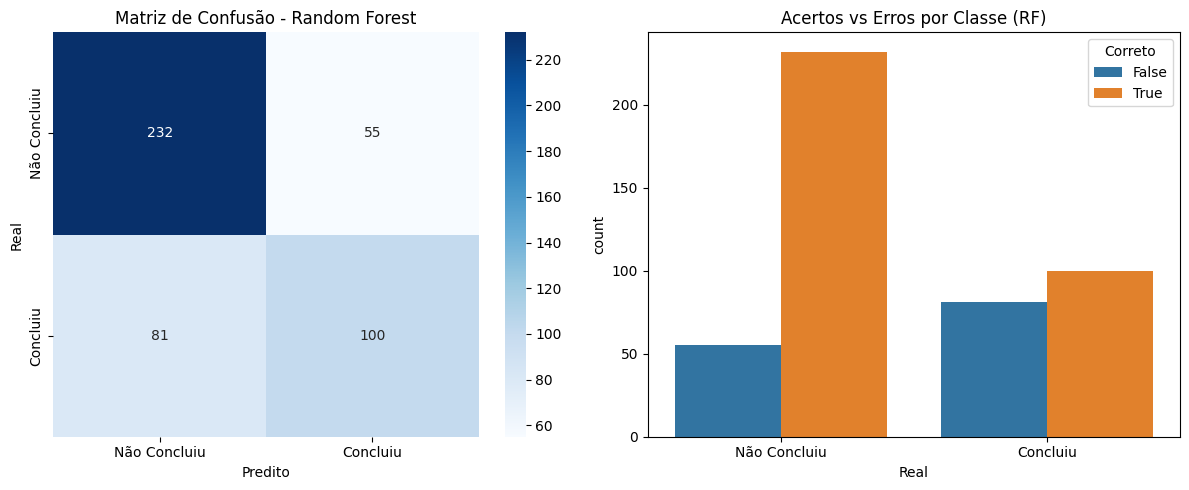

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gerar Matriz de Confusão para o Random Forest
cm_rf = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Matriz de Confusão
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão - Random Forest')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')
ax[0].set_xticklabels(['Não Concluiu', 'Concluiu'])
ax[0].set_yticklabels(['Não Concluiu', 'Concluiu'])

# Plot 2: Distribuição de Acertos vs Erros
results_rf = pd.DataFrame({'Real': y_test, 'Predito': y_pred})
results_rf['Correto'] = results_rf['Real'] == results_rf['Predito']
sns.countplot(x='Real', hue='Correto', data=results_rf, ax=ax[1])
ax[1].set_title('Acertos vs Erros por Classe (RF)')
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Não Concluiu', 'Concluiu'])

plt.tight_layout()
plt.show()

### Preparação do Modelo Sequencial (LSTM)
Vamos transformar a base sequencial em tensores tridimensionais `(amostras, passos_no_tempo, features)` para alimentar uma LSTM.

In [6]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Preparação da Base Sequencial com Filtro 2015-2024
# Garantir que temos o target 'concluiu' e o 'ano_ingresso' para o filtro
df_seq_mod = base_seq.copy()
if 'concluiu' not in df_seq_mod.columns:
    df_seq_mod = df_seq_mod.merge(base_flat[['id_discente', 'concluiu']], on='id_discente', how='left')

# Filtro temporal antes da criação de sequências
df_seq_mod = df_seq_mod.dropna(subset=['concluiu']) # remove quem ainda está ativo
df_seq_filtered = df_seq_mod[(df_seq_mod['ano_ingresso'] >= 2015) & (df_seq_mod['ano_ingresso'] < 2024)]
# print(df_seq_filtered.head(20))
df_seq_filtered = df_seq_filtered[df_seq_filtered['semestre_cronologico'] < 2]
# print(df_seq_filtered.head(20))

def create_sequences(df):
    feat_cols = [c for c in df.columns if c not in ['id_discente', 'concluiu', 'ano_ingresso', 'status_curso_encoded', 'periodo_ingresso']]
    sequences = []
    targets = []
    for _, group in df.sort_values(['id_discente', 'semestre_cronologico']).groupby('id_discente'):
        sequences.append(group[feat_cols].values)
        targets.append(group['concluiu'].iloc[0])
    return sequences, np.array(targets)

X_seq, y_seq = create_sequences(df_seq_filtered)

# 2. Divisão Aleatória padronizada
X_train_list, X_test_list, y_train_seq, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

train_concat = np.vstack(X_train_list)
scaler = StandardScaler()
scaler.fit(train_concat)

X_train_scaled = [scaler.transform(seq) for seq in X_train_list]
X_test_scaled = [scaler.transform(seq) for seq in X_test_list]

# 3. Padding
X_train_pad = pad_sequences(X_train_scaled, dtype='float32', padding='post')
X_test_pad = pad_sequences(X_test_scaled, dtype='float32', padding='post', maxlen=X_train_pad.shape[1])


# 4. Modelo LSTM
model_lstm = Sequential([
    Input(shape=(X_train_pad.shape[1], X_train_pad.shape[2])),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,649 (139.25 KB)

 Trainable params: 35,649 (139.25 KB)

 Non-trainable params: 0 (0.00 B)

### Treinamento e Avaliação do Modelo Sequencial
Finalizando o treinamento da rede neural para predição baseada no histórico temporal.

In [8]:
# Treinamento do modelo LSTM
history = model_lstm.fit(
    X_train_pad, y_train_seq,
    epochs=6,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Avaliação final no conjunto de teste sequencial
loss, accuracy = model_lstm.evaluate(X_test_pad, y_test_seq, verbose=0)
print(f"\nAcurácia do Modelo LSTM no Teste: {accuracy:.2f}")

Epoch 1/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6550 - loss: 0.5644 - val_accuracy: 0.8090 - val_loss: 0.4774
Epoch 2/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7698 - loss: 0.4848 - val_accuracy: 0.7921 - val_loss: 0.4412
Epoch 3/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7817 - loss: 0.4493 - val_accuracy: 0.7921 - val_loss: 0.4266
Epoch 4/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8011 - loss: 0.4273 - val_accuracy: 0.7753 - val_loss: 0.4264
Epoch 5/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8093 - loss: 0.4133 - val_accuracy: 0.7753 - val_loss: 0.4312
Epoch 6/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8149 - loss: 0.4015 - val_accuracy: 0.7697 - val_loss: 0.4331

Acurácia do Modelo LSTM no Teste: 0.80


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


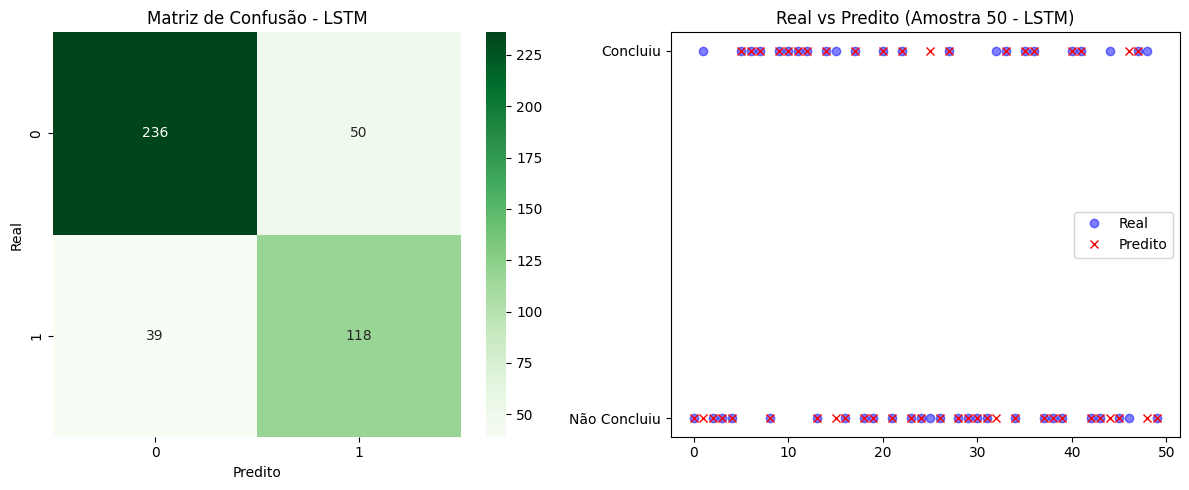

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Obter predições (probabilidades) e converter para classes (0 ou 1)
y_pred_lstm_prob = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

# 2. Gerar Matriz de Confusão
cm_lstm = confusion_matrix(y_test_seq, y_pred_lstm)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Matriz de Confusão
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Matriz de Confusão - LSTM')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')

# Plot 2: Comparativo Real vs Predito (Amostra de 50 alunos)
plt.subplot(1, 2, 2)
plt.plot(y_test_seq[:50], 'bo', label='Real', alpha=0.5)
plt.plot(y_pred_lstm[:50], 'rx', label='Predito')
plt.title('Real vs Predito (Amostra 50 - LSTM)')
plt.yticks([0, 1], ['Não Concluiu', 'Concluiu'])
plt.legend()

plt.tight_layout()
plt.show()

----
# Regressores
----

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Filtrar apenas alunos que concluíram o curso
df_reg = base_flat[base_flat['concluiu'] == 1].copy()

# 2. Aplicar o filtro de ano de ingresso (2015 a 2024) diretamente.
# A coluna 'ano_ingresso' já está presente em df_reg (originária de base_flat).
df_reg = df_reg[(df_reg['ano_ingresso'] >= 2015) & (df_reg['ano_ingresso'] < 2024)]

# 3. Definir target e remover colunas irrelevantes/socioeconômicas
socio_demo_cols = ['renda', 'sexo_encoded', 'ano_nascimento', 'raca_encoded',
                   'escola_ens_medio_encoded', 'cotista_encoded', 'sexo_encoded.1']
drop_cols_reg = ['id_discente', 'concluiu', 'semestres_para_concluir', 'semestres_para_concluir.1', 'ano_ingresso'] + socio_demo_cols

X_reg = df_reg.drop(columns=[c for c in drop_cols_reg if c in df_reg.columns])
y_reg = df_reg['semestres_para_concluir']

# 4. Divisão Treino/Teste
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 5. Treinamento
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train_r, y_train_r)

# 6. Predição e Métricas
y_pred_r = regressor.predict(X_test_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print(f"Regressor Tempo de Conclusão (Filtro 2015-2024):")
print(f"MAE: {mae:.2f} semestres")
print(f"R²: {r2:.2f}")

Regressor Tempo de Conclusão (Filtro 2015-2024):
MAE: 1.40 semestres
R²: 0.62


### Análise de Resíduos e Padrões de Erro
Nesta seção, identificamos quais variáveis estão mais correlacionadas com os erros do modelo de regressão.

In [11]:
import pandas as pd
import numpy as np

# 1. Criar DataFrame de análise combinando features de teste e erros
analysis_df = X_test_r.copy()
analysis_df['erro_real'] = y_test_r - y_pred_r
analysis_df['erro_absoluto'] = np.abs(analysis_df['erro_real'])

# 2. Calcular correlação do erro absoluto com as features
# Isso ajuda a ver se o erro aumenta conforme certas variáveis aumentam
correlations = analysis_df.corr()['erro_absoluto'].sort_values(ascending=False)

print("Top 10 Variáveis mais associadas a erros maiores (Correlação com Erro Absoluto):")
display(correlations.head(11)) # 11 para pular o próprio erro_absoluto



Top 10 Variáveis mais associadas a erros maiores (Correlação com Erro Absoluto):


,erro_absoluto
erro_absoluto,1.000000
s3_faltas_no_periodo,0.279526
s3_total_faltas_acumulado,0.267519
s4_total_faltas_acumulado,0.265244
s1_ECT2307_status,0.219281
s1_ECT2307_nota,0.216497
s2_total_faltas_acumulado,0.197761
s2_ECT2307_status,0.183741
s2_ECT2302_status,0.175957
s1_ECT2205_nota,0.167748
